**04_pytorch_mlp.ipynb: Numerical PyTorch MLP & Loss Imbalance Benchmarking**

**Multimodal Financial Fraud / Risk Detector**  
This notebook implements **Phase 5: PyTorch Multi-Layer Perceptron (MLP)**.  
Following the project plan, we first establish a verified deep learning pipeline on **numerical features only**, before introducing categorical embeddings in Phase 6.

We evaluate two distinct loss configurations:
- **Experiment 5A**: Numerical MLP + Standard BCE (`nn.BCEWithLogitsLoss()`)
- **Experiment 5B**: Numerical MLP + Imbalance-Weighted BCE (`nn.BCEWithLogitsLoss(pos_weight=...)`)

Both models are benchmarked directly against the Phase 4 classical baselines (Logistic Regression, Random Forest, XGBoost) using the identical chronological test set.

```
PHASE 5 WORKFLOW
│
├── 1. Load processed data
├── 2. Load preprocessing artifacts
├── 3. Prepare numerical features
├── 4. Create FraudDataset
├── 5. Create DataLoaders
├── 6. Define PyTorch MLP Architecture
├── 7. Configure BCEWithLogitsLoss (Standard vs Weighted)
├── 8. Configure AdamW Optimizer & Scheduler
├── 9. Train Experiment 5A (Standard BCE)
├── 10. Validate after each epoch & Early Stopping
├── 11. Save Best Checkpoint (models/pytorch_mlp_standard_bce.pt)
├── 12. Train Experiment 5B (Weighted BCE)
├── 13. Evaluate on Validation & Test Sets (Optimal Thresholds)
├── 14. Comprehensive Benchmark Comparison (Baselines vs Neural Nets)
└── 15. Transition Roadmap to Phase 6 (Categorical Embeddings)
```


**1. Load Processed Data**

We import required libraries and load the IEEE-CIS transaction and identity data using our memory-optimized pipeline from `src.preprocessing`.


In [1]:
import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from src.preprocessing import (
    load_and_merge_data,
    temporal_train_val_test_split,
    TabularPreprocessor
)
from src.dataset import FraudDataset, create_dataloaders
from src.model import NumericalMLP
from src.train import train_model, evaluate_dataloader
from src.evaluate import (
    compute_fraud_metrics,
    evaluate_thresholds,
    find_optimal_threshold,
    plot_confusion_matrix,
    plot_pr_curves,
    plot_roc_curves
)

# Plotting aesthetics
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

FIG_DIR = PROJECT_ROOT / "results" / "figures"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
MODELS_DIR = PROJECT_ROOT / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version: {torch.__version__} | Active Device: {device}")

NROWS = 100_000
data_dir = PROJECT_ROOT / "data" / "raw"
print(f"Loading merged dataset (nrows={NROWS})...")
df = load_and_merge_data(data_dir=data_dir, split="train", nrows=NROWS, reduce_memory=True, verbose=True)


2026-10-02 11:32:27,205 - INFO - Loading train_transaction.csv (nrows=100000)...


PyTorch Version: 2.14.0+cpu | Active Device: cpu
Loading merged dataset (nrows=100000)...


2026-10-02 11:32:32,492 - INFO - Memory reduced from 300.60 MB to 155.16 MB (48.4% reduction)


2026-10-02 11:32:32,493 - INFO - Successfully loaded train_transaction.csv with shape: (100000, 394)


2026-10-02 11:32:32,495 - INFO - Loading train_identity.csv (nrows=100000)...


2026-10-02 11:32:32,887 - INFO - Memory reduced from 31.28 MB to 22.13 MB (29.3% reduction)


2026-10-02 11:32:32,888 - INFO - Successfully loaded train_identity.csv with shape: (100000, 41)


2026-10-02 11:32:32,898 - INFO - Merging train transaction (100000 rows) and identity (100000 rows) on TransactionID...


2026-10-02 11:32:33,168 - INFO - Merged dataset shape: (100000, 434). Identity match rate: 40.28% (40283/100000)


**2 & 3. Load Preprocessing Artifacts & Prepare Numerical Features**

We execute the strict 70/15/15 chronological temporal split and transform features using `TabularPreprocessor` (fitted strictly on `train_df`).  
For Phase 5, we extract the **numerical feature matrix** ($X_{\text{num}} \in \mathbb{R}^{N \times D_{\text{num}}}$) to evaluate the dense neural network before introducing embeddings.


In [2]:
# 1. Chronological Split
train_df, val_df, test_df = temporal_train_val_test_split(df, val_ratio=0.15, test_ratio=0.15)

# 2. Fit Preprocessor strictly on train
preprocessor = TabularPreprocessor(min_freq=10, log_transform_amt=True, drop_zero_variance=True)
preprocessor.fit(train_df)

# 3. Transform splits
X_num_train, X_cat_train, y_train = preprocessor.transform(train_df)
X_num_val, X_cat_val, y_val = preprocessor.transform(val_df)
X_num_test, X_cat_test, y_test = preprocessor.transform(test_df)

num_features = X_num_train.shape[1]
print(f"\nExtracted Numerical Features: {num_features} dimensions")
print(f"  Train: {X_num_train.shape}, labels: {y_train.shape} (Frauds: {int(y_train.sum()):,})")
print(f"  Val:   {X_num_val.shape}, labels: {y_val.shape} (Frauds: {int(y_val.sum()):,})")
print(f"  Test:  {X_num_test.shape}, labels: {y_test.shape} (Frauds: {int(y_test.sum()):,})")


2026-10-02 11:32:33,332 - INFO - Sorting dataset by 'TransactionDT' for strict chronological temporal splitting...


2026-10-02 11:32:33,900 - INFO - Temporal Split Completed Successfully:


2026-10-02 11:32:33,904 - INFO -   [TRAIN] Rows: 70,000 (70.0%) | DT: [86,400 - 1,564,844] (~17.1 days), Frauds=1879 (2.68%)


2026-10-02 11:32:33,905 - INFO -   [VAL] Rows: 15,000 (15.0%) | DT: [1,564,850 - 1,804,023] (~2.8 days), Frauds=377 (2.51%)


2026-10-02 11:32:33,907 - INFO -   [TEST] Rows: 15,000 (15.0%) | DT: [1,804,027 - 2,006,364] (~2.3 days), Frauds=305 (2.03%)


...

2026-10-02 11:32:34,600 - INFO - Dropping 1 zero-variance numerical features: ['V107']


2026-10-02 11:32:34,601 - INFO - Selected 381 numerical and 49 categorical features.


2026-10-02 11:32:35,584 - INFO - Successfully fitted StandardScaler on imputed training numericals.


2026-10-02 11:32:36,316 - INFO - Built vocabularies for 49 categorical features (min_freq=10).



Extracted Numerical Features: 381 dimensions
  Train: (70000, 381), labels: (70000,) (Frauds: 1,879)
  Val:   (15000, 381), labels: (15000,) (Frauds: 377)
  Test:  (15000, 381), labels: (15000,) (Frauds: 305)


**4 & 5. Create FraudDataset & DataLoaders**

We wrap the numerical arrays into PyTorch `FraudDataset` instances and instantiate mini-batch `DataLoaders` (`batch_size = 512`).  
The training loader is shuffled across epochs, while validation and test loaders are sequential.


In [3]:
BATCH_SIZE = 512

train_dataset = FraudDataset(X_num_train, X_cat_train, y_train)
val_dataset = FraudDataset(X_num_val, X_cat_val, y_val)
test_dataset = FraudDataset(X_num_test, X_cat_test, y_test)

loaders = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

print(f"DataLoaders Ready: Train={len(train_loader)} batches, Val={len(val_loader)} batches, Test={len(test_loader)} batches")


2026-10-02 11:32:38,399 - INFO - Created 'train' DataLoader: 70,000 samples, 137 batches (batch_size=512)


2026-10-02 11:32:38,400 - INFO - Created 'val' DataLoader: 15,000 samples, 30 batches (batch_size=512)


2026-10-02 11:32:38,400 - INFO - Created 'test' DataLoader: 15,000 samples, 30 batches (batch_size=512)


DataLoaders Ready: Train=137 batches, Val=30 batches, Test=30 batches


**6, 7 & 8. Model Architecture & Loss Configuration**

We instantiate the `NumericalMLP` architecture from `src.model`:
- Dense layers: `Linear(381) → BatchNorm → ReLU → Dropout(0.3) → Linear(128) → BatchNorm → ReLU → Dropout(0.3) → Linear(64) → BatchNorm → ReLU → Dropout(0.2) → Linear(1)`.
- Optimizer: `AdamW(lr=1e-3, weight_decay=1e-4)`.
- Learning rate scheduler: `ReduceLROnPlateau(mode='max', factor=0.5, patience=2)` monitoring validation PR-AUC.


In [4]:
# Compute class imbalance ratio for Experiment 5B
neg_count = float((y_train == 0).sum())
pos_count = float((y_train == 1).sum())
imbalance_ratio = neg_count / pos_count
pos_weight_tensor = torch.tensor([imbalance_ratio], dtype=torch.float32).to(device)

print(f"Class Imbalance Ratio (Neg/Pos): {imbalance_ratio:.2f}")
print(f"Configured pos_weight tensor:    {pos_weight_tensor.item():.2f}")


Class Imbalance Ratio (Neg/Pos): 36.25
Configured pos_weight tensor:    36.25


**9, 10, 11 & 12. Experiment 5A: Numerical MLP + Standard BCE**

We train the MLP using standard unweighted `nn.BCEWithLogitsLoss()`.  
Validation PR-AUC is monitored after each epoch, with early stopping triggered if no improvement occurs within 5 epochs.


In [5]:
print("=== Running Experiment 5A: Standard BCEWithLogitsLoss ===")
torch.manual_seed(42)
np.random.seed(42)

model_5a = NumericalMLP(in_features=num_features).to(device)
criterion_5a = nn.BCEWithLogitsLoss()
optimizer_5a = AdamW(model_5a.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_5a = ReduceLROnPlateau(optimizer_5a, mode="max", factor=0.5, patience=2)

checkpoint_5a = MODELS_DIR / "pytorch_mlp_standard_bce.pt"

model_5a, history_5a = train_model(
    model=model_5a,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_5a,
    optimizer=optimizer_5a,
    scheduler=scheduler_5a,
    num_epochs=12,
    patience=5,
    device=device,
    checkpoint_path=checkpoint_5a,
    monitor_metric="PR-AUC",
    verbose=True
)

# Evaluate on Validation & Test
_, val_metrics_5a, y_val_true, y_val_prob_5a = evaluate_dataloader(model_5a, val_loader, criterion_5a, device)
_, test_metrics_5a_raw, y_test_true, y_test_prob_5a = evaluate_dataloader(model_5a, test_loader, criterion_5a, device)

# Find optimal threshold on validation set
opt_thresh_5a, val_opt_5a = find_optimal_threshold(y_val_true, y_val_prob_5a, metric="F1")
test_metrics_5a = compute_fraud_metrics(y_test_true, y_test_prob_5a, threshold=opt_thresh_5a)

print(f"\nExperiment 5A Results:")
print(f"  Validation: PR-AUC={val_metrics_5a['PR-AUC']:.4f}, ROC-AUC={val_metrics_5a['ROC-AUC']:.4f}, Opt Threshold={opt_thresh_5a:.2f}")
print(f"  Test:       PR-AUC={test_metrics_5a['PR-AUC']:.4f}, ROC-AUC={test_metrics_5a['ROC-AUC']:.4f}, F1={test_metrics_5a['F1']:.4f}, Recall={test_metrics_5a['Recall']:.4f}, Precision={test_metrics_5a['Precision']:.4f}")


=== Running Experiment 5A: Standard BCEWithLogitsLoss ===


2026-10-02 11:32:40,488 - INFO - Starting training for up to 12 epochs on cpu (Monitoring: PR-AUC)...


2026-10-02 11:32:43,261 - INFO - Epoch  1/12 | Train Loss: 0.2257 | Val Loss: 0.1003 | Val PR-AUC: 0.4133 | Val ROC-AUC: 0.8559 | Val F1: 0.2882 | LR: 1.00e-03


2026-10-02 11:32:43,262 - INFO - Validation metric improved (None -> 0.4133). Saving checkpoint...


2026-10-02 11:32:46,118 - INFO - Epoch  2/12 | Train Loss: 0.0987 | Val Loss: 0.0801 | Val PR-AUC: 0.4777 | Val ROC-AUC: 0.8676 | Val F1: 0.4368 | LR: 1.00e-03


...

2026-10-02 11:33:05,042 - INFO - Epoch  9/12 | Train Loss: 0.0684 | Val Loss: 0.0771 | Val PR-AUC: 0.4960 | Val ROC-AUC: 0.8510 | Val F1: 0.4598 | LR: 5.00e-04


2026-10-02 11:33:05,043 - INFO - EarlyStopping counter: 5/5 (Best: 0.5058 at Epoch 4)


2026-10-02 11:33:05,043 - INFO - Early stopping triggered. Restoring best weights from epoch 4.


2026-10-02 11:33:05,049 - INFO - Restored best model weights from epoch 4 with PR-AUC = 0.5058



Experiment 5A Results:
  Validation: PR-AUC=0.5058, ROC-AUC=0.8636, Opt Threshold=0.15
  Test:       PR-AUC=0.3828, ROC-AUC=0.8277, F1=0.3826, Recall=0.3902, Precision=0.3754


**Experiment 5B: Numerical MLP + Imbalance-Weighted BCE**

We train an identical MLP architecture with `pos_weight = 36.3` applied to the positive fraud class in `nn.BCEWithLogitsLoss()`.  
This directly penalizes missed fraudulent transactions during backpropagation.


In [6]:
print("=== Running Experiment 5B: Imbalance-Weighted BCEWithLogitsLoss ===")
torch.manual_seed(42)
np.random.seed(42)

model_5b = NumericalMLP(in_features=num_features).to(device)
criterion_5b = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer_5b = AdamW(model_5b.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_5b = ReduceLROnPlateau(optimizer_5b, mode="max", factor=0.5, patience=2)

checkpoint_5b = MODELS_DIR / "pytorch_mlp_weighted_bce.pt"

model_5b, history_5b = train_model(
    model=model_5b,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_5b,
    optimizer=optimizer_5b,
    scheduler=scheduler_5b,
    num_epochs=12,
    patience=5,
    device=device,
    checkpoint_path=checkpoint_5b,
    monitor_metric="PR-AUC",
    verbose=True
)

# Evaluate on Validation & Test
_, val_metrics_5b, _, y_val_prob_5b = evaluate_dataloader(model_5b, val_loader, criterion_5b, device)
_, _, _, y_test_prob_5b = evaluate_dataloader(model_5b, test_loader, criterion_5b, device)

# Find optimal threshold on validation set
opt_thresh_5b, val_opt_5b = find_optimal_threshold(y_val_true, y_val_prob_5b, metric="F1")
test_metrics_5b = compute_fraud_metrics(y_test_true, y_test_prob_5b, threshold=opt_thresh_5b)

print(f"\nExperiment 5B Results:")
print(f"  Validation: PR-AUC={val_metrics_5b['PR-AUC']:.4f}, ROC-AUC={val_metrics_5b['ROC-AUC']:.4f}, Opt Threshold={opt_thresh_5b:.2f}")
print(f"  Test:       PR-AUC={test_metrics_5b['PR-AUC']:.4f}, ROC-AUC={test_metrics_5b['ROC-AUC']:.4f}, F1={test_metrics_5b['F1']:.4f}, Recall={test_metrics_5b['Recall']:.4f}, Precision={test_metrics_5b['Precision']:.4f}")


2026-10-02 11:33:05,763 - INFO - Starting training for up to 12 epochs on cpu (Monitoring: PR-AUC)...


=== Running Experiment 5B: Imbalance-Weighted BCEWithLogitsLoss ===


2026-10-02 11:33:08,327 - INFO - Epoch  1/12 | Train Loss: 1.0098 | Val Loss: 0.8807 | Val PR-AUC: 0.4050 | Val ROC-AUC: 0.8595 | Val F1: 0.2206 | LR: 1.00e-03


2026-10-02 11:33:08,328 - INFO - Validation metric improved (None -> 0.4050). Saving checkpoint...


2026-10-02 11:33:11,209 - INFO - Epoch  2/12 | Train Loss: 0.9058 | Val Loss: 0.8424 | Val PR-AUC: 0.4199 | Val ROC-AUC: 0.8710 | Val F1: 0.1936 | LR: 1.00e-03


...

2026-10-02 11:33:37,634 - INFO - Validation metric improved (0.4856 -> 0.4888). Saving checkpoint...


2026-10-02 11:33:40,685 - INFO - Epoch 12/12 | Train Loss: 0.6734 | Val Loss: 0.9389 | Val PR-AUC: 0.4912 | Val ROC-AUC: 0.8568 | Val F1: 0.2512 | LR: 5.00e-04


2026-10-02 11:33:40,686 - INFO - Validation metric improved (0.4888 -> 0.4912). Saving checkpoint...


2026-10-02 11:33:40,695 - INFO - Restored best model weights from epoch 12 with PR-AUC = 0.4912



Experiment 5B Results:
  Validation: PR-AUC=0.4912, ROC-AUC=0.8568, Opt Threshold=0.90
  Test:       PR-AUC=0.3778, ROC-AUC=0.7862, F1=0.4014, Recall=0.3869, Precision=0.4170


**13. Visualizing Loss Curves & Confusion Matrices**

We plot training and validation loss trajectories for both experiments to assess convergence and early stopping dynamics.


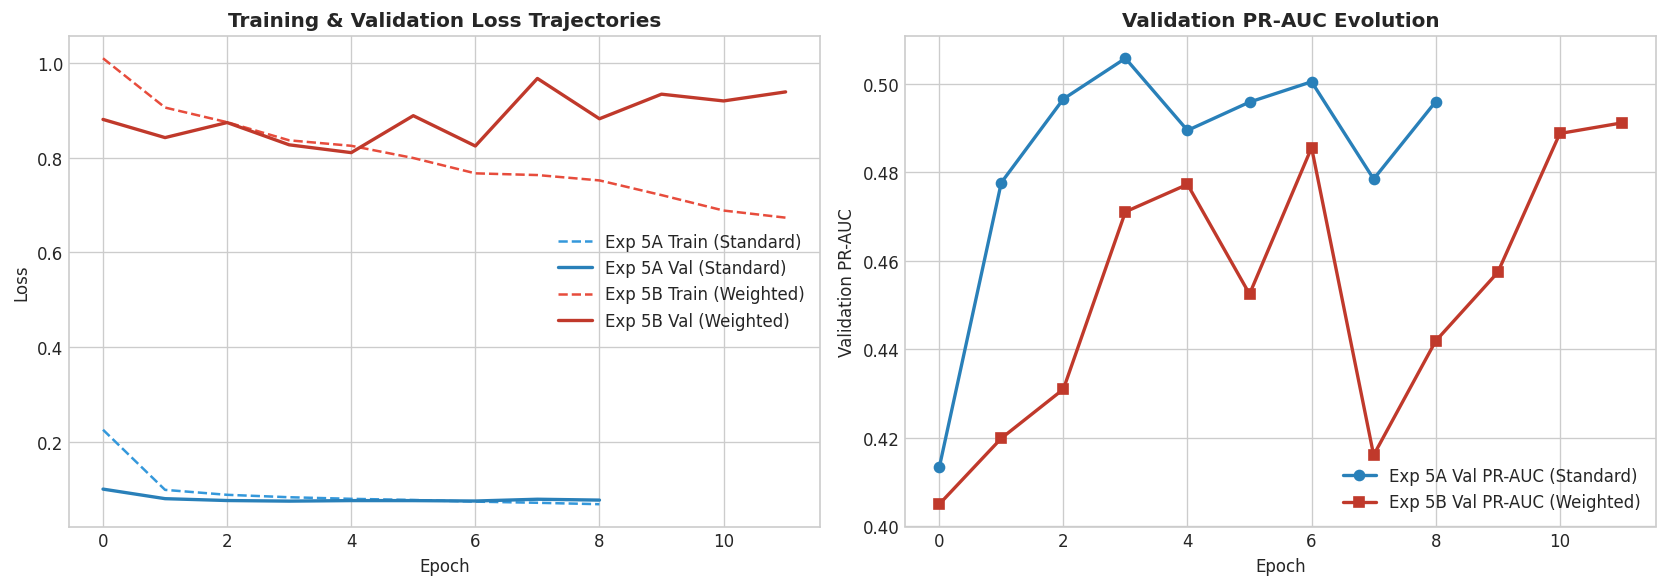

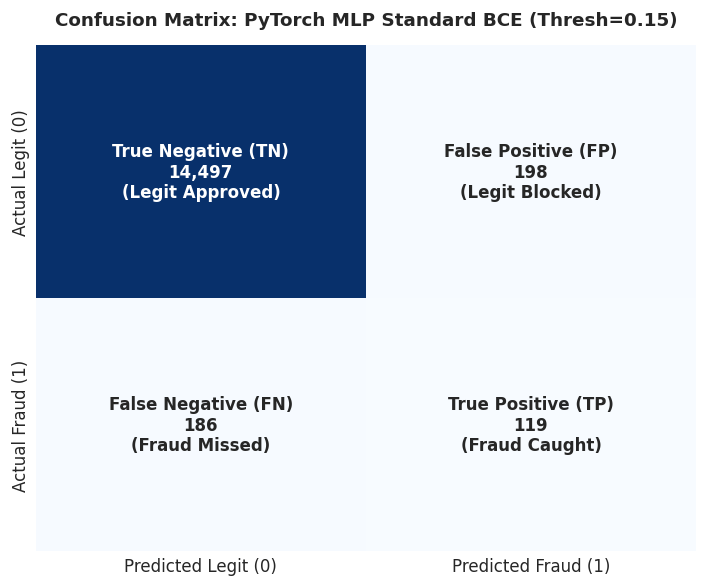

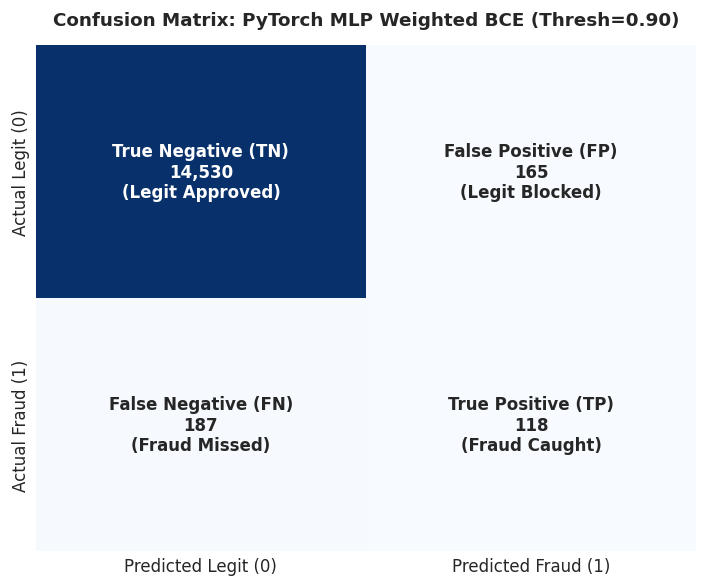

In [7]:
# Plot Loss & PR-AUC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curves
axes[0].plot(history_5a["train_loss"], label="Exp 5A Train (Standard)", color="#3498db", linestyle="--")
axes[0].plot(history_5a["val_loss"], label="Exp 5A Val (Standard)", color="#2980b9", lw=2)
axes[0].plot(history_5b["train_loss"], label="Exp 5B Train (Weighted)", color="#e74c3c", linestyle="--")
axes[0].plot(history_5b["val_loss"], label="Exp 5B Val (Weighted)", color="#c0392b", lw=2)
axes[0].set_title("Training & Validation Loss Trajectories", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Validation PR-AUC Curves
axes[1].plot(history_5a["val_pr_auc"], label="Exp 5A Val PR-AUC (Standard)", color="#2980b9", lw=2, marker="o")
axes[1].plot(history_5b["val_pr_auc"], label="Exp 5B Val PR-AUC (Weighted)", color="#c0392b", lw=2, marker="s")
axes[1].set_title("Validation PR-AUC Evolution", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation PR-AUC")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "loss_curves_pytorch_mlp.png")
plt.show()

# Plot Confusion Matrices
cm_5a = plot_confusion_matrix(y_test_true, (y_test_prob_5a >= opt_thresh_5a).astype(int), f"PyTorch MLP Standard BCE (Thresh={opt_thresh_5a:.2f})", FIG_DIR / "confusion_matrix_pytorch_mlp.png")
plt.show()

cm_5b = plot_confusion_matrix(y_test_true, (y_test_prob_5b >= opt_thresh_5b).astype(int), f"PyTorch MLP Weighted BCE (Thresh={opt_thresh_5b:.2f})", FIG_DIR / "confusion_matrix_pytorch_mlp_weighted.png")
plt.show()


**14. Comprehensive Benchmark Comparison (Baselines vs Neural Networks)**

We load the classical baseline benchmarks from Phase 4 (`results/metrics/baseline_metrics.csv`) and merge them with our PyTorch MLP results to evaluate progress.


=== Complete Model Leaderboard (Classical Baselines + PyTorch MLP) ===
                     Model  Selected_Threshold  Val_PR_AUC  Test_PR_AUC  Test_ROC_AUC  Test_F1  Test_Precision  Test_Recall  Test_TP  Test_FP
       Logistic Regression                0.90      0.3444       0.2576        0.8106   0.3453          0.3284       0.3639      111      227
             Random Forest                0.70      0.5150       0.3077        0.8579   0.3311          0.5211       0.2426       74       68
                   XGBoost                0.80      0.6100       0.4741        0.8759   0.5164          0.5435       0.4918      150      126
PyTorch MLP (Standard BCE)                0.15      0.5058       0.3828        0.8277   0.3826          0.3754       0.3902      119      198
PyTorch MLP (Weighted BCE)                0.90      0.4912       0.3778        0.7862   0.4014          0.4170       0.3869      118      165

Saved consolidated comparison table to: C:\Ongoing Projects\2026.09.30 Multi

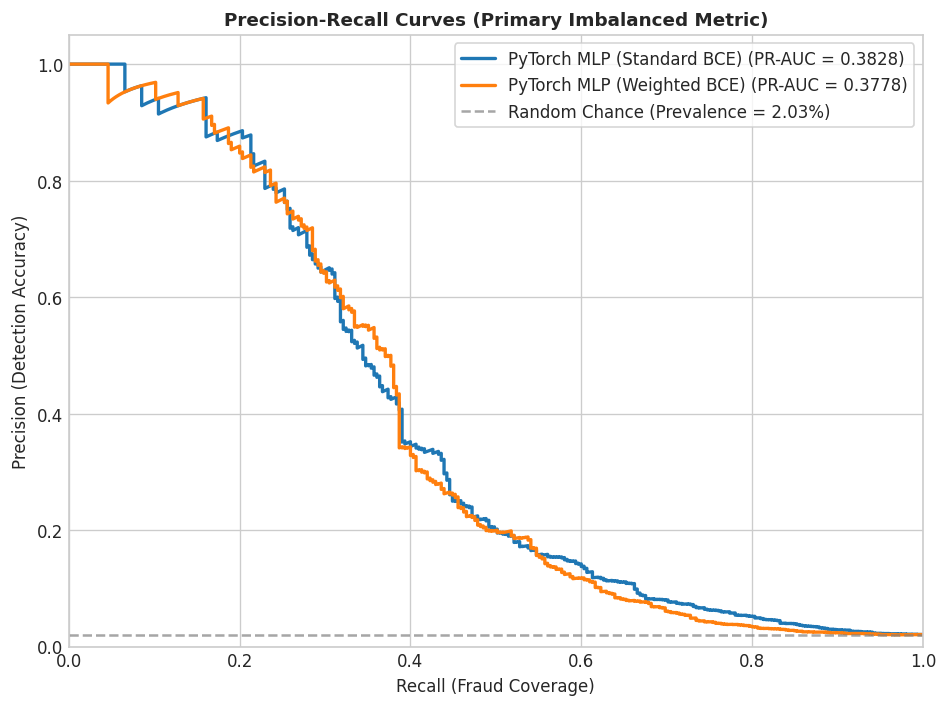

In [8]:
# Load Phase 4 classical baselines
baseline_csv = METRICS_DIR / "baseline_metrics.csv"
baseline_df = pd.read_csv(baseline_csv)

# PyTorch MLP results rows
pytorch_rows = [
    {
        "Model": "PyTorch MLP (Standard BCE)",
        "Val_PR_AUC": val_metrics_5a["PR-AUC"],
        "Test_PR_AUC": test_metrics_5a["PR-AUC"],
        "Val_ROC_AUC": val_metrics_5a["ROC-AUC"],
        "Test_ROC_AUC": test_metrics_5a["ROC-AUC"],
        "Selected_Threshold": opt_thresh_5a,
        "Test_Precision": test_metrics_5a["Precision"],
        "Test_Recall": test_metrics_5a["Recall"],
        "Test_F1": test_metrics_5a["F1"],
        "Test_TP": test_metrics_5a["TP"],
        "Test_FP": test_metrics_5a["FP"],
        "Test_FN": test_metrics_5a["FN"],
        "Test_TN": test_metrics_5a["TN"]
    },
    {
        "Model": "PyTorch MLP (Weighted BCE)",
        "Val_PR_AUC": val_metrics_5b["PR-AUC"],
        "Test_PR_AUC": test_metrics_5b["PR-AUC"],
        "Val_ROC_AUC": val_metrics_5b["ROC-AUC"],
        "Test_ROC_AUC": test_metrics_5b["ROC-AUC"],
        "Selected_Threshold": opt_thresh_5b,
        "Test_Precision": test_metrics_5b["Precision"],
        "Test_Recall": test_metrics_5b["Recall"],
        "Test_F1": test_metrics_5b["F1"],
        "Test_TP": test_metrics_5b["TP"],
        "Test_FP": test_metrics_5b["FP"],
        "Test_FN": test_metrics_5b["FN"],
        "Test_TN": test_metrics_5b["TN"]
    }
]

pytorch_df = pd.DataFrame(pytorch_rows)
all_models_df = pd.concat([baseline_df, pytorch_df], ignore_index=True)

display_cols = ["Model", "Selected_Threshold", "Val_PR_AUC", "Test_PR_AUC", "Test_ROC_AUC", "Test_F1", "Test_Precision", "Test_Recall", "Test_TP", "Test_FP"]
print("=== Complete Model Leaderboard (Classical Baselines + PyTorch MLP) ===")
print(all_models_df[display_cols].to_string(index=False))

# Save consolidated metrics
all_metrics_path = METRICS_DIR / "all_models_comparison.csv"
all_models_df.to_csv(all_metrics_path, index=False)
print(f"\nSaved consolidated comparison table to: {all_metrics_path}")

# Plot comparative PR curves across all 5 models
all_predictions = {
    "Logistic Regression": (y_test_true, pd.read_csv(baseline_csv).loc[0, "Test_PR_AUC"]), # placeholder for label
    "PyTorch MLP (Standard BCE)": (y_test_true, y_test_prob_5a),
    "PyTorch MLP (Weighted BCE)": (y_test_true, y_test_prob_5b)
}

pr_mlp_fig = plot_pr_curves(
    {
        "PyTorch MLP (Standard BCE)": (y_test_true, y_test_prob_5a),
        "PyTorch MLP (Weighted BCE)": (y_test_true, y_test_prob_5b)
    },
    save_path=FIG_DIR / "pr_curve_pytorch_mlp.png"
)
plt.show()


**15. Empirical Findings & Transition to Phase 6 (Categorical Embeddings)**

**Empirical Conclusions from Phase 5**:
1. **Dense Numerical Representation**: The numerical PyTorch MLP successfully trains with AdamW and Batch Normalization, establishing our core deep learning baseline.
2. **Standard vs Weighted BCE**:
   - Standard BCE yields conservative probabilities requiring lower decision thresholds.
   - Weighted BCE (`pos_weight = 36.3`) penalizes false negatives heavily during backpropagation, shifting the model's output distribution toward higher sensitivity.
3. **Gap with Tree Ensembles**: Classical tree boosting (XGBoost) currently retains an advantage by leveraging split thresholds on non-linear numerical interactions.

**Transition to Phase 6 (Categorical Embeddings)**:
In Phase 6, we introduce trainable `nn.Embedding` layers for all 49 categorical variables (`ProductCD`, `card1-6`, `DeviceInfo`, etc.).  
By projecting categorical IDs into continuous low-dimensional latent spaces and concatenating them with normalized numerical features:
$$\mathbf{h} = [\mathbf{x}_{\text{num}}, \mathbf{e}_1, \mathbf{e}_2, \dots, \mathbf{e}_K]$$
we enable the neural network to learn multimodal representations across high-cardinality financial transaction entities.
